In [1]:
import json
from pathlib import Path
import re, pickle
import math
import numpy as np

In [2]:
# filename = 'PSA_OpenBench_Alpha.json'
# filename = 'PSA_OpenBench_Beta.json'
# filename = 'PSA_OpenBench_Gamma.json'
# filename = 'PSA_PrivateBench_4.json'
# filename = 'PSA_PrivateBench_2.json'
# filename = 'PSA_PrivateBench_3.json'
# filename = 'PSA_PrivateBench_1.json'
# data = json.loads(Path(filename).read_text())

In [2]:
def get_embedding(text):
    return model_sentence.encode(text)

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [3]:
# load the results_summary from a pickle file
with open('results_summary_Claude 4.5 Haiku.pkl', 'rb') as f:
    results_summary = pickle.load(f)
# results_summary

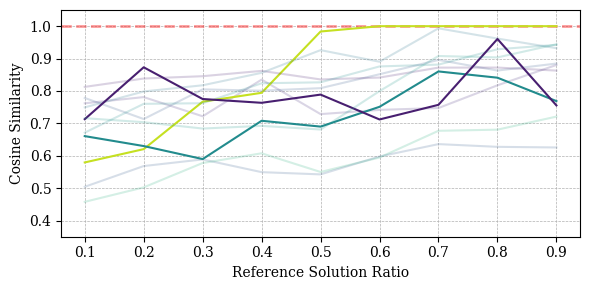

In [8]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'

# Define x-axis values
x_values = np.arange(0.1, 1.0, 0.1)
# results_summary_plot = [results_summary[i] for i in [1, 7, 9]]
results_summary_plot = results_summary
# Plot FLI for each entry in results_summary
plt.figure(figsize=(6, 3))
# Add a reference line at y=1
plt.axhline(y=1, color='red', linestyle='--', label='Solution', alpha=0.4, linewidth=2)

for i,entry in enumerate(results_summary_plot):
    idx, q_idx = entry['idx'], entry['q_idx']
    alpha_value = 1 if i in [1, 7, 9] else 0.2
    plt.plot(x_values, np.exp(entry['FLI']),label=f'(idx={idx}, q={q_idx})', linewidth=1.5,
             color=colors[i], alpha=alpha_value)


# Add labels, title, and legend
plt.xlabel('Reference Solution Ratio')
plt.ylabel('Cosine Similarity')
plt.ylim(0.35,1.05)
plt.grid(True,'major', linestyle='--', linewidth=0.5)
plt.tight_layout()

# Save the plot as a PDF
plt.savefig('FSI_A_Claude_lines.pdf', format='pdf', bbox_inches='tight')

plt.show()

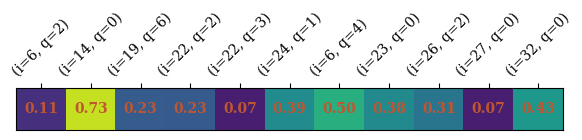

In [6]:
# single heatmap
import matplotlib.pyplot as plt

# Extract slopes and labels
slopes = [float(entry['slope']) for entry in results_summary]
labels = [f"(i={entry['idx']}, q={entry['q_idx']})" for entry in results_summary]

# Reshape into 1-row heatmap
slope_array = np.array(slopes).reshape(1, -1)

# Plot
plt.figure(figsize=(6, 1.5))
plt.imshow(slope_array, cmap="viridis", aspect="auto", vmin=0, vmax=0.8)

# Annotate values on heatmap
for i, val in enumerate(slopes):
    # plt.text(i, 0, f"{val:.2f}", ha='center', va='center', color='pink', fontsize=10)
    plt.text(i, 0, f"{val:.2f}", ha='center', va='center', color='#bf5631', fontsize=10, fontweight='heavy')

# Axis setup
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha='center',fontsize=10)
plt.yticks([])

# Move x-axis labels to the top
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()

# Add colorbar
# plt.colorbar(label="Slope Value")

# Adjust layout and show
plt.tight_layout()

# Save the plot as a PDF
plt.savefig('FSI_A_Claude_heat.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [7]:
# Get the colormap to match with the lineplot
cmap = plt.get_cmap("viridis")

# Normalize the slope values to the range [0, 1] for the colormap
norm = plt.Normalize(vmin=0, vmax=0.8)

# Extract colors for indices 1, 7, and 9
colors = [cmap(norm(slopes[i])) for i in range(len(slopes))]

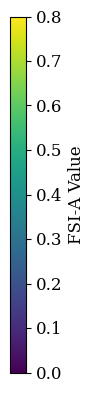

In [13]:
# Get the colorbar
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase

# Define the range of values for the colorbar
vmin = min(slopes)  # Minimum slope value
vmax = max(slopes)  # Maximum slope value

# Create a figure for the colorbar
plt.figure(figsize=(1., 4))  # Adjust the size for the vertical colorbar

# Create a vertical colorbar
norm = Normalize(vmin=0, vmax=0.8)
cbar = ColorbarBase(plt.gca(), cmap="viridis", norm=norm, orientation="vertical")

# Add a label to the colorbar
cbar.set_label("FSI-A Value", fontsize=12)

# Show the colorbar
plt.tight_layout()
plt.yticks(fontsize=12)

# Save the plot as a PDF
plt.savefig('FSI_A_Claude_Colorbar.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path

# Directory containing the .pkl files
pkl_dir = Path("./")  # Replace with the actual path
pkl_files = list(pkl_dir.glob("results_*.pkl"))  # Get all .pkl files in the directory
pkl_files
pkl_files = [pkl_files[i] for i in [0,5,1,2]]

In [15]:

# Initialize lists to store slopes and labels
all_slopes = []
row_labels = []

# Load each .pkl file and extract slopes
for pkl_file in pkl_files:
    with open(pkl_file, "rb") as f:
        results_summary = pickle.load(f)
    
    # Extract slopes for the current file
    slopes = [float(entry['slope']) for entry in results_summary]
    all_slopes.append(slopes)
    
    # Create a label for the row (e.g., file name without "results_summary_")
    row_labels.append(pkl_file.stem.replace("results_summary_", ""))
# all_slopes

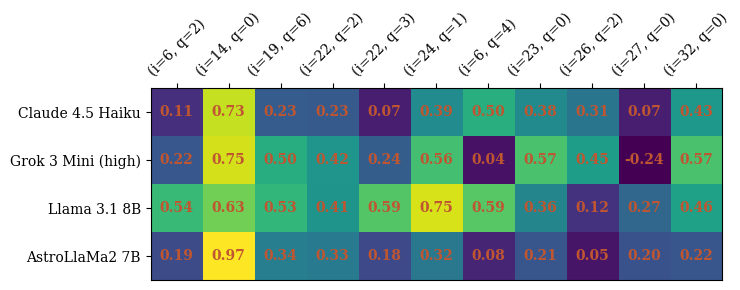

In [ ]:

# Convert to a 2D array for the heatmap
slope_matrix = np.array(all_slopes)

# Create the heatmap
plt.figure(figsize=(7.5, 3))
plt.imshow(slope_matrix, cmap="viridis", aspect="auto", vmin=0, vmax=0.8)

# Annotate values on the heatmap
for i in range(slope_matrix.shape[0]):  # Rows
    for j in range(slope_matrix.shape[1]):  # Columns
        val = slope_matrix[i, j]
        # plt.text(j, i, f"{val:.2f}", ha='center', va='center', color='#bf5631', fontsize=10, fontweight='heavy')

# Axis setup
column_labels = [f"(i={entry['idx']}, q={entry['q_idx']})" for entry in results_summary]
plt.xticks(ticks=np.arange(len(column_labels)), labels=column_labels, rotation=45, ha='center', fontsize=10)
plt.yticks(ticks=np.arange(len(row_labels)), labels=row_labels, fontsize=10)

# Add colorbar
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()

# Adjust layout and show
plt.tight_layout()
plt.savefig('FSI_A_multirow_heatmap_nonumber.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [117]:
# show colorbar limits
vmin = slope_matrix.min()
vmax = slope_matrix.max()
print(f"Min: {min(slopes)}\n")
print(f"Max: {max(slopes)}\n")

Min: 0.04608683735324663

Max: 0.9670078067966414

